In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ml_assessment_data/q3_retail_promotions.csv')

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Mounted at /content/drive
Shape: (1200, 9)
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         obj

In [2]:
# Convert transaction_date to a proper datetime type
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date parts
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Create is_month_end: 1 if day of month >= 25, else 0
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Confirm new columns
print("New date-derived columns:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))
print("\nValue counts for is_month_end:")
print(df['is_month_end'].value_counts())

New date-derived columns:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0

Value counts for is_month_end:
is_month_end
0    959
1    241
Name: count, dtype: int64


In [3]:
# Sort by date (oldest first)
df = df.sort_values('transaction_date').reset_index(drop=True)

# Calculate split point: 80% train, 20% test
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

print(f"Total records:  {len(df)}")
print(f"Training rows:  {len(train_df)}")
print(f"Test rows:      {len(test_df)}")
print(f"\nTraining period: {train_df['transaction_date'].min()} → {train_df['transaction_date'].max()}")
print(f"Test period:     {test_df['transaction_date'].min()} → {test_df['transaction_date'].max()}")

Total records:  1200
Training rows:  960
Test rows:      240

Training period: 2022-01-01 00:00:00 → 2024-06-11 00:00:00
Test period:     2024-06-12 00:00:00 → 2024-12-31 00:00:00


### Why a Random Split is Inappropriate for Time-Ordered Data

In a standard random split, data points from any time period can end up in
either the training or test set. This causes **data leakage** — the model
effectively "sees the future" during training if December data appears in
training while March data is in the test set.

For time-series or temporal data, the model must be evaluated on data it
has NEVER seen before AND that comes AFTER the training period. This mimics
the real deployment scenario: you train on historical data and predict the
next month's sales. A random split produces overly optimistic performance
metrics that won't hold in production.

In [4]:
# Define features and target
TARGET = 'items_sold'
DROP_COLS = ['transaction_date', TARGET]

# Categorical columns to one-hot encode
cat_features = ['promotion_type', 'location_type', 'store_size']

# Numerical features to scale (everything else except drop cols and cat cols)
all_features = [c for c in df.columns if c not in DROP_COLS]
num_features = [c for c in all_features if c not in cat_features]

print("Categorical features:", cat_features)
print("Numerical features:", num_features)

# Prepare X and y
X_train = train_df[all_features]
y_train = train_df[TARGET]
X_test  = test_df[all_features]
y_test  = test_df[TARGET]

# Build the ColumnTransformer
# This applies different transformations to different columns in one step

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    # handle_unknown='ignore' prevents errors if test set has a category not in training
])

print("Preprocessor defined successfully!")
print("Numerical columns will be scaled.")
print("Categorical columns will be one-hot encoded.")

Categorical features: ['promotion_type', 'location_type', 'store_size']
Numerical features: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Preprocessor defined successfully!
Numerical columns will be scaled.
Categorical columns will be one-hot encoded.


Both pipelines trained!

Linear Regression:
  RMSE: 27.12  (Root Mean Squared Error — penalises large errors more)
  MAE:  21.05   (Mean Absolute Error — average error in items)

Random Forest:
  RMSE: 30.84  (Root Mean Squared Error — penalises large errors more)
  MAE:  24.31   (Mean Absolute Error — average error in items)


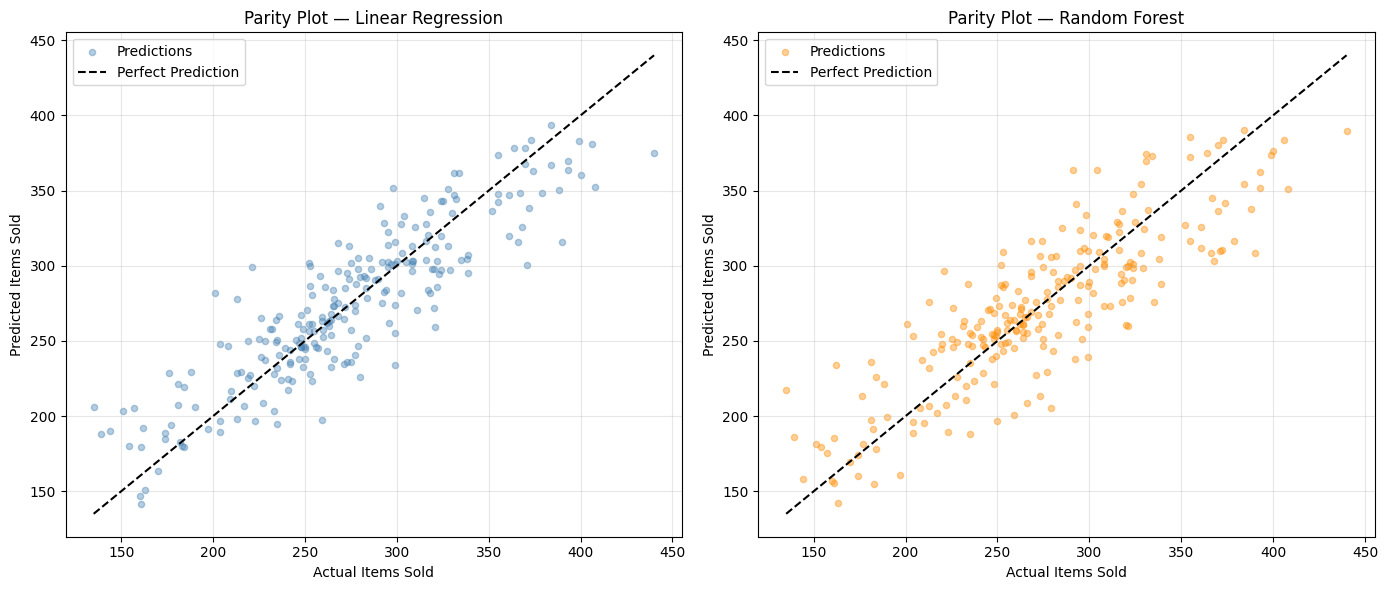

Top 5 Most Important Features:
            Feature  Importance
        is_festival    0.173413
   store_size_small    0.166752
location_type_urban    0.108505
        day_of_week    0.080552
         is_weekend    0.067103


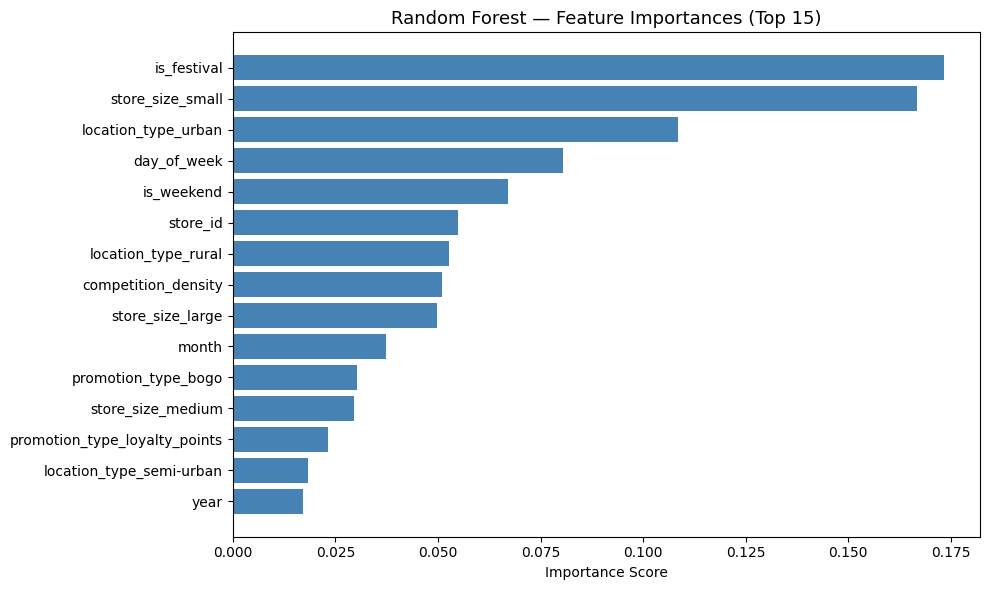

In [7]:
# Build pipelines — one per model
# The pipeline: Preprocessor → Model (in sequence)

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit ONLY on training data
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print("Both pipelines trained!")


# Predict on test data
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluation metrics
def evaluate_regression(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.2f}  (Root Mean Squared Error — penalises large errors more)")
    print(f"  MAE:  {mae:.2f}   (Mean Absolute Error — average error in items)")
    return rmse, mae

rmse_lr, mae_lr = evaluate_regression(y_test, y_pred_lr, "Linear Regression")
rmse_rf, mae_rf = evaluate_regression(y_test, y_pred_rf, "Random Forest")

# Parity Plots — Predicted vs Actual
# A perfect model's points fall exactly on the diagonal line (y = x).
# Points above the line = model under-predicted.
# Points below the line = model over-predicted.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, model_name, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test, y_pred, alpha=0.4, color=color, s=20, label='Predictions')

    # Diagonal reference line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='Perfect Prediction')

    ax.set_title(f'Parity Plot — {model_name}', fontsize=12)
    ax.set_xlabel('Actual Items Sold')
    ax.set_ylabel('Predicted Items Sold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importances from Random Forest
# This tells us which features the Random Forest relied on most to make predictions.

# Get feature names after one-hot encoding
ohe = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

importances = pipeline_rf.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 5 Most Important Features:")
print(feature_importance_df.head(5).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 6))
top15 = feature_importance_df.head(15)
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1], color='steelblue')
plt.title('Random Forest — Feature Importances (Top 15)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()